# BTC Orderbook LSTM — run.004 (long-timescale features + 1h horizon + multi-seed)

**Why:** run.002 (big classification LSTM) and run.003 (small regression LSTM + XGBoost) both landed at test IC ≈ 0 on the same 35 features — two model families agreeing means the *inputs*, not capacity, are the constraint. But the inputs only cover a 64-bar (16-min) window: the model is blind to trend/vol regime beyond that, and the 2–10 min horizons sit below the fee floor (~$30–40 round trip). run.004 attacks both from the **existing v1 dataset** before falling back to v3-collector data.

**Three changes vs run.003 (everything else frozen):**

1. **Long-timescale context features** (offline, causal, no lookahead) — vol-normalised returns and MA gaps at 1h/4h/24h, 1h/24h vol-regime ratio, position in 24h range, spot–futures **basis** (4h z-score + 1h momentum, from `spot_bid/ask_close` which were never used), day-of-week. Computed with *time-based* rolling windows on the datetime index, so collector gaps and restart offsets can't corrupt them. Continuous MA *distances* rather than binary crossings — same information, dense instead of rare 0/1 spikes.
2. **New horizon h=240 (1 h), `H_TRADE=240`** — where trend features have known predictive power and where the fee floor is beatable. h=8 and h=40 heads are kept, so their per-fold ICs are directly comparable to run.003 (pure feature effect).
3. **Multi-seed evaluation (3 seeds/fold)** — run.003 showed val-IC-based epoch selection is ≈ random on overlapping labels (fold-0 val +0.054 → test −0.007). Report per-seed spread, seed-ensemble ICs, and **daily-IC t-stats**; backtest scores are per-fold normalised by validation score std so σ-thresholds are meaningful.

**Decision rules:**
- h8/h40 ICs vs run.003 → did the new features add anything at short horizons at all?
- h240: ensemble IC consistent in sign across folds **and** daily-IC |t| > 2 → pursue (threshold tuning, longer training); otherwise —
- XGB per-feature importance: if the new features rank low *and* ICs are unchanged → the v1 dataset is exhausted; stop feature work and wait for v3/schema-4 collector data.

Inherited from run.003: move-weighted sampling + |y|-weighted Huber (now keyed to the 1h target), vol-normalised regression targets, gap-aware pipeline, coverage guard, 4-fold purged walk-forward, position-based backtest with hysteresis + per-side fees, zero-copy window batching (T4 / 12 GB RAM safe).

Expected runtime on a T4: **roughly 2–4 h total** (3 seeds ≈ 3× the LSTM training of run.003; XGB unchanged).

## Setup
1. Runtime → Change runtime type → **T4 GPU**
2. Run all cells in order

In [1]:
# ── Cell 1: Install and imports ───────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'torch',
                'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'scipy',
                'xgboost'], check=True)

import os, glob, gc, math, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# ── Cell 2: (optional) data transfer helpers — uncomment what you need ────
#!apt install sshpass -y && sshpass -p XXXXXXXXXX sftp -r -o "StrictHostKeyChecking no" scpuser@155.207.120.2:btc_data.tar.xz .
#from google.colab import drive
#drive.mount('/content/drive')
#!mv btc_data.tar.xz /content/drive/MyDrive/
#!ls /content/drive/MyDrive/ -l
#drive.flush_and_unmount()

In [3]:
from google.colab import drive
drive.mount('/content/drive')

!cd ~ && mkdir -p btc_lstm_v2
!cd ~ && tar xJf /content/drive/MyDrive/btc_data.tar.xz

drive.flush_and_unmount()

Mounted at /content/drive


In [4]:
# ── Cell 3: Mount Google Drive, extract data, config ─────────────────────


# ── CONFIGURE THESE ───────────────────────────────────────────────────────
DATA_DIR   = '/root/btc_data'
OUTPUT_DIR = '/root/btc_lstm_run004'

WINDOW_SEC  = 15          # bar size produced by the collector
HORIZONS    = [8, 40, 240]  # 2 min / 10 min (run.003 comparison) / 1 h (new)
H_TRADE     = 240         # horizon used for trading / backtest / early stopping
VOL_WINDOW  = 240         # 1h rolling window for target normalisation
TARGET_CLIP = 5.0         # clip |target| at 5 sigma

SEQ_LEN      = 64         # 16 min of context
HIDDEN_DIM   = 128        # SMALL on purpose — run.001 overfit already at 212K params
NUM_LAYERS   = 2
DROPOUT      = 0.3
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 2048
EPOCHS       = 12
WARMUP       = 2          # linear warmup epochs before cosine decay
PATIENCE     = 5          # early stop on val rank-IC of the trading head
EPOCH_SAMPLE_CAP = 600_000  # train sequences drawn per epoch (weighted, w/ replacement)

# ── run.003 (kept): focus training on directional bars ──
SAMPLE_W_BASE = 0.25      # epoch-draw probability ∝ SAMPLE_W_BASE + |y_trade|
LOSS_W_ALPHA  = 1.0       # per-sample Huber weight = min(1 + α·|y_trade|, cap)
LOSS_W_CAP    = 4.0

# ── run.004: multi-seed evaluation ──
SEEDS = [0, 1, 2]         # per-fold; test score = seed-ensemble mean
MIN_DAY_SAMPLES = 500     # a test day needs this many samples to enter daily-IC stats

N_FOLDS         = 4       # walk-forward folds over the last 60% of the data
TEST_START_FRAC = 0.40    # first 40% is never tested (training warmup)
VAL_FRAC        = 0.12    # tail of each training range used for early stopping
COVERAGE_MIN    = 0.60    # features with lower non-NaN coverage are excluded

MAKER_FEE = 0.0002        # per side (Binance USDT-M futures maker)
TAKER_FEE = 0.0005        # per side
ENTER_THRESHOLDS = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0]  # entry, in predicted-sigma units
EXIT_FRAC = 0.3           # exit when |score| drops below EXIT_FRAC * enter_thr

RUN_XGB_BASELINE = True
# ─────────────────────────────────────────────────────────────────────────

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Data dir:   {DATA_DIR}')
print(f'Output dir: {OUTPUT_DIR}')

Data dir:   /root/btc_data
Output dir: /root/btc_lstm_run004


In [5]:
# ── Cell 4: Feature pipeline ──────────────────────────────────────────────
SEPARATOR = ';'

COLS_NEEDED_BASE = {
    'spot_datetime', 'future_datetime', 'spot_timestamp', 'future_timestamp',
    'future_bid_close', 'future_ask_close',
    'future_bid_open', 'future_bid_max', 'future_bid_min',
    'future_bid_median', 'future_ask_median',
    'future_spread_open', 'future_spread_max',
    'future_buy_qty', 'future_sell_qty',
    'future_buy_samples', 'future_sell_samples',
    'future_buy_vwap', 'future_sell_vwap', 'future_price_diff',
    'future_bid_liq_0.0_median', 'future_ask_liq_0.0_median',
    'spot_buy_qty', 'spot_sell_qty',
    'spot_bid_close', 'spot_ask_close',
    'opt_open_interest_sample', 'opt_funding_rate_sample',
    'opt_est_funding_rate_sample', 'opt_remaining_time_sample',
    'opt_long_force_exit_qty_sum', 'opt_short_force_exit_qty_sum',
    'future_first_trade_side', 'future_last_trade_side',
    'future_largest_trade_qty', 'future_largest_trade_side',
    'future_buy_count_early', 'future_buy_count_late',
    'future_sell_count_early', 'future_sell_count_late',
    'future_buy_qty_early', 'future_buy_qty_late',
    'future_sell_qty_early', 'future_sell_qty_late',
}
COLS_NEEDED_LIQ_DEEP  = [
    'future_bid_liq_0.04_median', 'future_ask_liq_0.04_median',
    'future_bid_liq_0.05_median', 'future_ask_liq_0.05_median',
    'future_bid_liq_0.06_median', 'future_ask_liq_0.06_median',
]
COLS_NEEDED_LIQ_TOTAL = [
    'future_bid_liq_0.1_median',  'future_ask_liq_0.1_median',
    'future_bid_liq_0.2_median',  'future_ask_liq_0.2_median',
    'future_bid_liq_0.3_median',  'future_ask_liq_0.3_median',
    'future_bid_liq_0.4_median',  'future_ask_liq_0.4_median',
]

# run.004: long-timescale context the 64-bar input window cannot see
NEW_FEATURES = [
    'ret_norm_1h', 'ret_norm_4h', 'ret_norm_24h',
    'ma_gap_1h', 'ma_gap_4h', 'ma_gap_24h',
    'vol_ratio_1h_24h', 'range_pos_24h',
    'basis_z_4h', 'basis_mom_1h',
    'dow_sin', 'dow_cos',
]

ALL_FEATURES = [
    'book_imbalance', 'flow_imbalance', 'momentum', 'book_imbal_deep',
    'flow_imbal_roll4', 'flow_imbal_roll8', 'book_imbal_roll4', 'book_imbal_roll8',
    'vwap_spread', 'liq_flag', 'stochastic', 'spread_expansion', 'sample_imbalance',
    'flow_agreement', 'oi_change', 'size_imbalance', 'liq_conc_bid', 'liq_conc_ask',
    'hour_sin', 'hour_cos', 'minute_sin', 'minute_cos',
    'near_funding', 'funding_pressure', 'vol_norm',
    'trade_side_open', 'trade_side_close', 'trade_side_momentum',
    'largest_trade_side', 'largest_trade_rel',
    'buy_accel', 'sell_accel', 'flow_accel', 'buy_count_accel', 'late_imbalance',
] + NEW_FEATURES


def load_files(files):
    all_needed = COLS_NEEDED_BASE | set(COLS_NEEDED_LIQ_DEEP) | set(COLS_NEEDED_LIQ_TOTAL)
    frames = []
    for path in files:
        try:
            hdr = pd.read_csv(path, sep=SEPARATOR, nrows=0)
            usecols = sorted(all_needed & set(hdr.columns))
            if 'spot_datetime' not in usecols:
                print(f'  SKIP {os.path.basename(path)}: missing spot_datetime')
                continue
            df = pd.read_csv(path, sep=SEPARATOR, usecols=usecols, low_memory=False)
            df = df[df['spot_datetime'] != 'spot_datetime']
            frames.append(df)
        except Exception as e:
            print(f'  SKIP {os.path.basename(path)}: {e}')
    if not frames:
        raise RuntimeError('No valid CSV files found.')
    print(f'  Loaded {len(frames)} files')
    return pd.concat(frames, ignore_index=True)


def prepare(df, horizons, vol_window):
    df['dt'] = pd.to_datetime(df['spot_datetime'], errors='coerce')
    df = df.dropna(subset=['dt']).sort_values('dt').reset_index(drop=True)
    n_before = len(df)
    df = df.drop_duplicates(subset='dt', keep='first').reset_index(drop=True)
    if len(df) < n_before:
        print(f'  Dropped {n_before - len(df)} duplicate timestamps')

    skip = {'spot_datetime', 'future_datetime', 'dt'}
    for col in df.columns:
        if col not in skip:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    for col in [c for c in df.columns if c.startswith('opt_')]:
        df[col] = df[col].replace(-1, np.nan)

    if 'future_bid_close' in df.columns and 'future_ask_close' in df.columns:
        df['close_price'] = (df['future_bid_close'] + df['future_ask_close']) / 2.0
    else:
        df['close_price'] = (df['future_bid_median'] + df['future_ask_median']) / 2.0

    # Gap structure: collector restarts / dropped bars break the 15s cadence.
    gap = df['dt'].diff().dt.total_seconds()
    n_breaks = int((gap != WINDOW_SEC).sum()) - 1
    big = gap[gap > 3600]
    print(f'  Cadence breaks: {n_breaks}  (gaps >1h: {len(big)}, largest: {gap.max()/3600:.1f}h)')

    eps = 1e-9
    df['flow_imbalance'] = ((df['future_buy_qty'] - df['future_sell_qty']) /
                            (df['future_buy_qty'] + df['future_sell_qty'] + eps))
    bid0 = df['future_bid_liq_0.0_median']
    ask0 = df['future_ask_liq_0.0_median']
    df['book_imbalance'] = (bid0 - ask0) / (bid0 + ask0 + eps)
    df['momentum'] = df['future_price_diff']

    deep_col = None
    for lvl in ['0.05', '0.04', '0.06']:
        b, a = f'future_bid_liq_{lvl}_median', f'future_ask_liq_{lvl}_median'
        if b in df.columns and a in df.columns:
            deep_col = (b, a); break
    df['book_imbal_deep'] = ((df[deep_col[0]] - df[deep_col[1]]) /
                             (df[deep_col[0]] + df[deep_col[1]] + eps)) if deep_col else np.nan

    df['flow_imbal_roll4'] = df['flow_imbalance'].rolling(4, min_periods=2).mean()
    df['flow_imbal_roll8'] = df['flow_imbalance'].rolling(8, min_periods=4).mean()
    df['book_imbal_roll4'] = df['book_imbalance'].rolling(4, min_periods=2).mean()
    df['book_imbal_roll8'] = df['book_imbalance'].rolling(8, min_periods=4).mean()

    df['vwap_spread'] = (df['future_buy_vwap'] - df['future_sell_vwap']
                         if 'future_buy_vwap' in df.columns else np.nan)
    liq_long  = df.get('opt_long_force_exit_qty_sum',  pd.Series(0, index=df.index))
    liq_short = df.get('opt_short_force_exit_qty_sum', pd.Series(0, index=df.index))
    df['liq_flag'] = ((liq_long + liq_short) > 0).astype(float)

    if all(c in df.columns for c in ['future_bid_max', 'future_bid_min', 'future_bid_close']):
        rng = df['future_bid_max'] - df['future_bid_min']
        df['stochastic'] = np.where(rng > 0, (df['future_bid_close'] - df['future_bid_min']) / rng, 0.5)
    else:
        df['stochastic'] = np.nan

    df['spread_expansion'] = (df['future_spread_max'] - df['future_spread_open']
                              if all(c in df.columns for c in ['future_spread_max', 'future_spread_open'])
                              else np.nan)

    if all(c in df.columns for c in ['future_buy_samples', 'future_sell_samples']):
        bs, ss = df['future_buy_samples'], df['future_sell_samples']
        df['sample_imbalance'] = (bs - ss) / (bs + ss + eps)
    else:
        df['sample_imbalance'] = np.nan

    if all(c in df.columns for c in ['spot_buy_qty', 'spot_sell_qty']):
        spot_flow = ((df['spot_buy_qty'] - df['spot_sell_qty']) /
                     (df['spot_buy_qty'] + df['spot_sell_qty'] + eps))
        df['flow_agreement'] = df['flow_imbalance'] * spot_flow
    else:
        df['flow_agreement'] = np.nan

    df['oi_change'] = df['opt_open_interest_sample'].diff() if 'opt_open_interest_sample' in df.columns else np.nan

    if all(c in df.columns for c in ['future_buy_samples', 'future_sell_samples',
                                      'future_buy_qty', 'future_sell_qty']):
        df['size_imbalance'] = (df['future_buy_qty']  / (df['future_buy_samples']  + eps) -
                                df['future_sell_qty'] / (df['future_sell_samples'] + eps))
    else:
        df['size_imbalance'] = np.nan

    sub_cols = ['future_first_trade_side', 'future_last_trade_side',
                'future_largest_trade_qty', 'future_largest_trade_side',
                'future_buy_count_early', 'future_buy_count_late',
                'future_sell_count_early', 'future_sell_count_late',
                'future_buy_qty_early', 'future_buy_qty_late',
                'future_sell_qty_early', 'future_sell_qty_late']
    if all(c in df.columns for c in sub_cols):
        bqe, bql = df['future_buy_qty_early'],  df['future_buy_qty_late']
        sqe, sql = df['future_sell_qty_early'],  df['future_sell_qty_late']
        fts, lts = df['future_first_trade_side'], df['future_last_trade_side']
        lq,  ls  = df['future_largest_trade_qty'], df['future_largest_trade_side']
        bce, bcl = df['future_buy_count_early'], df['future_buy_count_late']
        total_vol = bqe + bql + sqe + sql
        df['trade_side_open']     = fts
        df['trade_side_close']    = lts
        df['trade_side_momentum'] = lts - fts
        df['largest_trade_side']  = ls
        df['largest_trade_rel']   = lq / (total_vol + eps)
        df['buy_accel']           = bql - bqe
        df['sell_accel']          = sql - sqe
        df['flow_accel']          = (bql - sql) - (bqe - sqe)
        df['buy_count_accel']     = bcl - bce
        df['late_imbalance']      = (bql - sql) / (bql + sql + eps)
    else:
        for c in ['trade_side_open','trade_side_close','trade_side_momentum',
                  'largest_trade_side','largest_trade_rel','buy_accel','sell_accel',
                  'flow_accel','buy_count_accel','late_imbalance']:
            df[c] = np.nan

    deep_bid = next((c for c in ['future_bid_liq_0.4_median','future_bid_liq_0.3_median',
                                  'future_bid_liq_0.2_median','future_bid_liq_0.1_median']
                     if c in df.columns), None)
    deep_ask = next((c for c in ['future_ask_liq_0.4_median','future_ask_liq_0.3_median',
                                  'future_ask_liq_0.2_median','future_ask_liq_0.1_median']
                     if c in df.columns), None)
    df['liq_conc_bid'] = (df['future_bid_liq_0.0_median'] / (df[deep_bid] + eps)
                          if deep_bid else np.nan)
    df['liq_conc_ask'] = (df['future_ask_liq_0.0_median'] / (df[deep_ask] + eps)
                          if deep_ask else np.nan)

    hour, minute = df['dt'].dt.hour, df['dt'].dt.minute
    df['hour_sin']   = np.sin(2 * np.pi * hour   / 24)
    df['hour_cos']   = np.cos(2 * np.pi * hour   / 24)
    df['minute_sin'] = np.sin(2 * np.pi * minute / 60)
    df['minute_cos'] = np.cos(2 * np.pi * minute / 60)

    secs = (hour * 3600 + minute * 60 + df['dt'].dt.second) % (8 * 3600)
    df['near_funding'] = ((8 * 3600 - secs) < 900).astype(float)
    if 'opt_funding_rate_sample' in df.columns:
        funding = df['opt_funding_rate_sample'].replace(-1, np.nan).fillna(0)
        df['funding_pressure'] = funding * df['near_funding']
    else:
        df['funding_pressure'] = np.nan

    df['volatility'] = df['close_price'].diff().abs().rolling(16, min_periods=4).mean()
    df['vol_norm']   = (df['volatility'] /
                        df['volatility'].rolling(5760, min_periods=96).mean()
                       ).replace([np.inf, -np.inf], np.nan)

    # ── run.004: long-timescale context features ─────────────────────────
    # All rolling windows are TIME-based on the datetime index (rolling('24h')),
    # not row-count based: collector restarts land on arbitrary second offsets
    # and gaps would otherwise stretch a "1h" window over more wall time.
    # Everything is causal (past data only) and vol-normalised so the scale is
    # stationary across regimes; clipped at ±8 to bound scaler-era outliers.
    D = 24 * 3600 // WINDOW_SEC              # bars per 24h at full cadence
    lp = pd.Series(np.log(df['close_price'].values), index=df['dt'])

    def past(series, delta, tol_sec=2 * WINDOW_SEC):
        # value of `series` ~delta earlier (nearest bar within tol), aligned back
        p = series.reindex(series.index - delta, method='nearest',
                           tolerance=pd.Timedelta(seconds=tol_sec))
        return pd.Series(p.values, index=series.index)

    r1 = lp.diff()
    r1[gap.values != WINDOW_SEC] = np.nan    # 1-bar return across a gap is not 1-bar
    sigma24 = r1.rolling('24h', min_periods=D // 4).std()

    for name, td, W in [('1h', pd.Timedelta(hours=1),  D // 24),
                        ('4h', pd.Timedelta(hours=4),  D // 6),
                        ('24h', pd.Timedelta(hours=24), D)]:
        unit = sigma24 * np.sqrt(W) + eps
        df[f'ret_norm_{name}'] = ((lp - past(lp, td)) / unit).clip(-8, 8).values
        ma = lp.rolling(td, min_periods=int(W * 0.75)).mean()
        df[f'ma_gap_{name}'] = ((lp - ma) / unit).clip(-8, 8).values

    vol1h = r1.rolling('1h', min_periods=D // 48).std()
    df['vol_ratio_1h_24h'] = (vol1h / (sigma24 + eps)).clip(0, 5).values

    hi24 = lp.rolling('24h', min_periods=D // 4).max()
    lo24 = lp.rolling('24h', min_periods=D // 4).min()
    df['range_pos_24h'] = ((lp - lo24) / (hi24 - lo24 + eps)).clip(0, 1).values

    if all(c in df.columns for c in ['spot_bid_close', 'spot_ask_close']):
        spot_mid = (df['spot_bid_close'] + df['spot_ask_close']) / 2.0
        basis = pd.Series(((df['close_price'] - spot_mid) / (spot_mid + eps)).values,
                          index=df['dt'])
        b_ma = basis.rolling('4h', min_periods=D // 12).mean()
        b_sd = basis.rolling('4h', min_periods=D // 12).std()
        df['basis_z_4h'] = ((basis - b_ma) / (b_sd + eps)).clip(-8, 8).values
        b_mom = basis - past(basis, pd.Timedelta(hours=1))
        b_mom_sd = b_mom.rolling('4h', min_periods=D // 12).std()
        df['basis_mom_1h'] = (b_mom / (b_mom_sd + eps)).clip(-8, 8).values
    else:
        df['basis_z_4h'] = np.nan
        df['basis_mom_1h'] = np.nan

    dow = df['dt'].dt.dayofweek
    df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
    df['dow_cos'] = np.cos(2 * np.pi * dow / 7)
    del lp, r1, sigma24, vol1h, hi24, lo24
    # ──────────────────────────────────────────────────────────────────────

    # Targets: volatility-normalised future return per horizon. A target is
    # valid only when the row h bars ahead really is h*15s ahead — no labels
    # across collector gaps. vol uses only past prices (no leakage).
    # (datetime64[s] cast is robust to the pandas 2/3 resolution change)
    dt_sec = pd.Series(df['dt'].values.astype('datetime64[s]').astype(np.int64),
                       index=df.index)
    for h in horizons:
        vol   = df['close_price'].diff(h).rolling(vol_window, min_periods=vol_window // 4).std()
        delta = df['close_price'].shift(-h) - df['close_price']
        y     = (delta / (vol + eps)).clip(-TARGET_CLIP, TARGET_CLIP)
        valid = (dt_sec.shift(-h) - dt_sec) == h * WINDOW_SEC
        y[~valid.fillna(False)] = np.nan
        df[f'y_{h}'] = y
    return df

print('Feature pipeline loaded.')

Feature pipeline loaded.


In [6]:
# ── Cell 5: Load data, coverage guard, build arrays ───────────────────────
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')) +
               glob.glob(os.path.join(DATA_DIR, '*.csv.gz')))
print(f'Found {len(files)} files')

raw = load_files(files)
print(f'Total rows loaded: {len(raw):,}')

df = prepare(raw, HORIZONS, VOL_WINDOW)
del raw; gc.collect()

# Coverage guard: a feature that exists only in the newer collector files
# (e.g. sub-bar features present only in ~15 days of v2 data) would otherwise
# make dropna() silently discard the entire older year of data.
features = []
for f_ in ALL_FEATURES:
    if f_ not in df.columns:
        continue
    cov = df[f_].notna().mean()
    if cov >= COVERAGE_MIN:
        features.append(f_)
    else:
        print(f'  EXCLUDED {f_:22s} coverage {cov*100:5.1f}% < {COVERAGE_MIN*100:.0f}%')
print(f'Features kept: {len(features)}/{len(ALL_FEATURES)}')

n0 = len(df)
clean = df[features + [f'y_{h}' for h in HORIZONS] + ['dt', 'close_price']]           .dropna(subset=features).reset_index(drop=True)
lost = n0 - len(clean)
print(f'Rows: {n0:,} → {len(clean):,} after dropna ({lost/max(n0,1)*100:.2f}% dropped)')
if lost > 0.05 * n0:
    print('\n*** WARNING: dropna removed >5% of rows — check per-feature NaN fractions: ***')
    print(df[features].isna().mean().sort_values(ascending=False).head(10))
del df; gc.collect()

X_raw  = clean[features].values.astype(np.float32)
Y_all  = np.stack([clean[f'y_{h}'].values for h in HORIZONS], axis=1).astype(np.float32)
dt_s   = clean['dt'].values.astype('datetime64[s]').astype(np.int64)
dt_all = clean['dt'].values
close  = clean['close_price'].values.astype(np.float64)
n, F_DIM = X_raw.shape
del clean; gc.collect()

# A sample "ends" at row i: input window = rows [i-SEQ_LEN+1, i], targets at
# i+h. Valid only if the window is contiguous 15s bars (dropna and collector
# gaps both break cadence, and the dt check catches both) and targets exist.
contig = np.zeros(n, dtype=bool)
span = (SEQ_LEN - 1) * WINDOW_SEC
contig[SEQ_LEN-1:] = (dt_s[SEQ_LEN-1:] - dt_s[:n-SEQ_LEN+1]) == span
sample_valid = contig & np.isfinite(Y_all).all(axis=1)
assert sample_valid.sum() > 0, 'No valid samples — check bar cadence / targets'

print(f'\nRows: {n:,}   valid samples: {sample_valid.sum():,} ({sample_valid.mean()*100:.1f}%)')
print(f'Date range: {pd.Timestamp(dt_all[0])} → {pd.Timestamp(dt_all[-1])}')
H_TRADE_IDX = HORIZONS.index(H_TRADE)
yt = Y_all[sample_valid, H_TRADE_IDX]
print(f'Trading target y_{H_TRADE}: std={yt.std():.3f}   |y|>1σ: {(np.abs(yt) > 1).mean()*100:.1f}%   '
      f'up share: {(yt > 0).mean()*100:.1f}%')

Found 1679 files
  Loaded 1679 files
Total rows loaded: 1,608,951
  Cadence breaks: 10494  (gaps >1h: 11, largest: 73.3h)
  EXCLUDED trade_side_open        coverage   0.0% < 60%
  EXCLUDED trade_side_close       coverage   0.0% < 60%
  EXCLUDED trade_side_momentum    coverage   0.0% < 60%
  EXCLUDED largest_trade_side     coverage   0.0% < 60%
  EXCLUDED largest_trade_rel      coverage   0.0% < 60%
  EXCLUDED buy_accel              coverage   0.0% < 60%
  EXCLUDED sell_accel             coverage   0.0% < 60%
  EXCLUDED flow_accel             coverage   0.0% < 60%
  EXCLUDED buy_count_accel        coverage   0.0% < 60%
  EXCLUDED late_imbalance         coverage   0.0% < 60%
Features kept: 37/47
Rows: 1,608,951 → 1,567,264 after dropna (2.59% dropped)

Rows: 1,567,264   valid samples: 847,666 (54.1%)
Date range: 2025-09-15 16:36:00 → 2026-07-04 00:36:15
Trading target y_240: std=2.193   |y|>1σ: 57.5%   up share: 49.9%


In [7]:
# ── Cell 6: Walk-forward folds (expanding window, purged) ─────────────────
MAX_H = max(HORIZONS)

def ends_in(a, b):
    return np.flatnonzero(sample_valid[a:b]) + a

test_start = int(n * TEST_START_FRAC)
chunk = (n - test_start) // N_FOLDS
folds = []
for k in range(N_FOLDS):
    lo = test_start + k * chunk
    hi = n if k == N_FOLDS - 1 else lo + chunk
    boundary = lo - MAX_H                     # purge: val labels must not reach into test
    val_lo   = int(boundary * (1 - VAL_FRAC))
    folds.append({'k': k,
                  'train_hi': val_lo - MAX_H,  # purge: train labels must not reach into val
                  'val':  (val_lo, boundary),
                  'test': (lo, hi)})

print('Fold   n_train     n_val    n_test    test period')
for f_ in folds:
    t_lo, t_hi = f_['test']
    n_tr = len(ends_in(0, f_['train_hi']))
    n_va = len(ends_in(*f_['val']))
    n_te = len(ends_in(t_lo, t_hi))
    assert min(n_tr, n_va, n_te) > 0, f"fold {f_['k']} has an empty split"
    print(f"  {f_['k']}  {n_tr:>9,}  {n_va:>8,}  {n_te:>8,}    "
          f"{pd.Timestamp(dt_all[t_lo])} → {pd.Timestamp(dt_all[t_hi-1])}")

Fold   n_train     n_val    n_test    test period
  0    351,759    37,741   129,789    2026-01-06 16:17:45 → 2026-02-21 18:59:30
  1    452,669    66,811   119,337    2026-02-21 18:59:45 → 2026-04-12 05:07:45
  2    581,423    57,354    84,631    2026-04-12 05:08:00 → 2026-05-23 15:22:15
  3    671,614    52,123   123,929    2026-05-23 15:22:30 → 2026-07-04 00:36:15


In [8]:
# ── Cell 7: Model — small LSTM, multi-horizon regression heads ────────────
class BtcLSTMReg(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, n_out):
        super().__init__()
        self.input_norm = nn.LayerNorm(input_dim)
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_dim, n_out))

    def forward(self, x):
        h, _ = self.lstm(self.input_norm(x))
        return self.head(h[:, -1])

_tmp = BtcLSTMReg(F_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(HORIZONS))
print(f'Model parameters: {sum(p.numel() for p in _tmp.parameters()):,}')
del _tmp

Model parameters: 218,061


In [9]:
# ── Cell 8: Training helpers (zero-copy window gathering, multi-seed) ─────
AMP = device.type == 'cuda'

def make_scheduler(opt, warmup, total):
    def fn(ep):
        if ep < warmup:
            return (ep + 1) / warmup
        prog = (ep - warmup) / max(total - warmup, 1)
        return 0.5 * (1 + math.cos(math.pi * prog))
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)

def ic(a, b):
    v = spearmanr(a, b)[0]
    return float(v) if np.isfinite(v) else 0.0

def predict(model, view, ends, batch=4096):
    model.eval()
    outs = []
    with torch.no_grad():
        for s in range(0, len(ends), batch):
            e = ends[s:s+batch]
            xb = torch.from_numpy(view[e - (SEQ_LEN - 1)]).to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=AMP):
                outs.append(model(xb).float().cpu())
    return torch.cat(outs).numpy()

def train_one_seed(seed, view, train_ends, val_ends, samp_p):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    model = BtcLSTMReg(F_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, len(HORIZONS)).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = make_scheduler(opt, WARMUP, EPOCHS)
    scaler_amp = torch.amp.GradScaler('cuda', enabled=AMP)

    best_ic, best_state, best_epoch, wait = -9.0, None, 0, 0
    hist = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        # weighted draw WITH replacement (weighted w/o replacement is O(k·n)
        # in numpy); duplicates are just oversampling, which is the point
        ep_ends = rng.choice(train_ends,
                             min(len(train_ends), EPOCH_SAMPLE_CAP),
                             replace=True, p=samp_p)
        tot, m = 0.0, 0
        for s in range(0, len(ep_ends), BATCH_SIZE):
            e = ep_ends[s:s+BATCH_SIZE]
            xb = torch.from_numpy(view[e - (SEQ_LEN - 1)]).to(device, non_blocking=True)
            yb = torch.from_numpy(Y_all[e]).to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=AMP):
                per = F.smooth_l1_loss(model(xb), yb, reduction='none').mean(dim=1)
                w = torch.clamp(1.0 + LOSS_W_ALPHA * yb[:, H_TRADE_IDX].abs(),
                                max=LOSS_W_CAP)
                loss = (w * per).sum() / w.sum()
            opt.zero_grad(set_to_none=True)
            scaler_amp.scale(loss).backward()
            scaler_amp.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler_amp.step(opt)
            scaler_amp.update()
            tot += loss.item() * len(e); m += len(e)
        sched.step()

        vp = predict(model, view, val_ends)
        v_ic = [ic(vp[:, i], Y_all[val_ends, i]) for i in range(len(HORIZONS))]
        hist.append({'train_loss': tot / m, 'val_ic': v_ic})
        cur = v_ic[H_TRADE_IDX]
        if cur > best_ic:
            best_ic, best_epoch, wait = cur, epoch, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            flag = '  ← best'
        else:
            wait += 1
            flag = f'  ({wait}/{PATIENCE})'
        ics = '  '.join(f'IC_h{h}={v:+.4f}' for h, v in zip(HORIZONS, v_ic))
        print(f'    seed {seed}  ep {epoch:2d}  loss={tot/m:.4f}  {ics}{flag}')
        if wait >= PATIENCE:
            print('    early stop')
            break

    model.load_state_dict(best_state)
    return model, best_state, best_epoch, hist

def train_fold(fold):
    t_hi = fold['train_hi']
    v0, v1 = fold['val']
    s0, s1 = fold['test']

    scaler = StandardScaler().fit(X_raw[:t_hi])
    Xs = scaler.transform(X_raw).astype(np.float32)
    # (n-SEQ_LEN+1, SEQ_LEN, F) VIEW into Xs — no copy; batches materialise
    # only when fancy-indexed below. This is what keeps RAM under control.
    view = np.lib.stride_tricks.sliding_window_view(Xs, (SEQ_LEN, F_DIM))[:, 0]

    train_ends = ends_in(0, t_hi)
    val_ends   = ends_in(v0, v1)
    test_ends  = ends_in(s0, s1)

    # Importance sampling: bars with bigger vol-normalised moves are drawn
    # more often; SAMPLE_W_BASE keeps flat bars in the mix so the model still
    # learns what "nothing happening" looks like.
    samp_w = SAMPLE_W_BASE + np.abs(Y_all[train_ends, H_TRADE_IDX]).astype(np.float64)
    samp_p = samp_w / samp_w.sum()
    eff = 1.0 / np.sum(samp_p ** 2) / len(samp_p)
    print(f'  sampling tilt: effective sample fraction {eff*100:.1f}% '
          f'(100% = uniform)')

    # run.004: identical training per seed; only the RNG differs. The test
    # score is the seed-ensemble mean; per-seed ICs expose how much of any
    # single-seed result is initialisation luck.
    states, best_epochs, hists = [], [], []
    val_preds, test_preds, seed_test_ic = [], [], []
    for seed in SEEDS:
        model, best_state, best_epoch, hist = train_one_seed(
            seed, view, train_ends, val_ends, samp_p)
        vp = predict(model, view, val_ends)
        tp = predict(model, view, test_ends)
        s_ic = [ic(tp[:, i], Y_all[test_ends, i]) for i in range(len(HORIZONS))]
        ics = '  '.join(f'IC_h{h}={v:+.4f}' for h, v in zip(HORIZONS, s_ic))
        print(f'    seed {seed} TEST: {ics}   (best epoch {best_epoch})')
        states.append(best_state); best_epochs.append(best_epoch); hists.append(hist)
        val_preds.append(vp); test_preds.append(tp); seed_test_ic.append(s_ic)
        del model

    val_pred  = np.mean(val_preds, axis=0)     # seed-ensemble
    test_pred = np.mean(test_preds, axis=0)
    test_ic = [ic(test_pred[:, i], Y_all[test_ends, i]) for i in range(len(HORIZONS))]
    out = {'scaler': scaler, 'states': states, 'best_epochs': best_epochs,
           'hist': hists[-1], 'val_ends': val_ends, 'val_pred': val_pred,
           'test_ends': test_ends, 'test_pred': test_pred,
           'test_ic': test_ic, 'seed_test_ic': seed_test_ic}
    del Xs, view
    gc.collect()
    return out

In [10]:
# ── Cell 9: Run walk-forward ──────────────────────────────────────────────
results = []
for fold in folds:
    lo, hi = fold['test']
    print(f"\n════ Fold {fold['k']}: test {pd.Timestamp(dt_all[lo])} → {pd.Timestamp(dt_all[hi-1])} ════")
    res = train_fold(fold)
    results.append(res)
    ics = '  '.join(f'IC_h{h}={v:+.4f}' for h, v in zip(HORIZONS, res['test_ic']))
    print(f"  ENSEMBLE TEST ({len(res['test_ends']):,} samples): {ics}")

print('\n──── Walk-forward summary (seed-ensemble; ± = per-seed spread) ────')
hdr = '  '.join(f"{'IC_h' + str(h):>16s}" for h in HORIZONS)
print(f'Fold    n_test   {hdr}')
for f_, r in zip(folds, results):
    cells = []
    for j in range(len(HORIZONS)):
        s_ics = [r['seed_test_ic'][s][j] for s in range(len(SEEDS))]
        cells.append(f"{r['test_ic'][j]:>+8.4f} ±{np.std(s_ics):.4f}")
    print(f"  {f_['k']}   {len(r['test_ends']):>8,}  " + '  '.join(cells))

ends_pool = np.concatenate([r['test_ends'] for r in results])
pred_pool = np.concatenate([r['test_pred'] for r in results])
pooled_ic = [ic(pred_pool[:, i], Y_all[ends_pool, i]) for i in range(len(HORIZONS))]
print('Pooled ensemble:   ' + '  '.join(f'{v:>+9.4f}       ' for v in pooled_ic))

# Backtest/pooling score: per-fold predictions divided by that fold's
# VALIDATION score std, so "σ" entry thresholds mean the same thing in every
# fold and the score scale is chosen without touching test data.
score_pool = np.concatenate([r['test_pred'] / (r['val_pred'].std(axis=0) + 1e-9)
                             for r in results])

# Daily IC: one IC per test day, then a t-stat across days. Labels overlap
# heavily WITHIN a day, but day-level ICs are close to independent draws —
# this is the noise-aware number to compare between runs.
def daily_ic_stats(ends, score, y):
    days = dt_all[ends].astype('datetime64[D]')
    vals = []
    for d in np.unique(days):
        m = days == d
        if m.sum() >= MIN_DAY_SAMPLES:
            vals.append(ic(score[m], y[m]))
    vals = np.array(vals)
    se = vals.std(ddof=1) / np.sqrt(len(vals))
    return vals.mean(), se, vals.mean() / se, len(vals)

print('\n──── Daily-IC t-stats (pooled ensemble; |t|>2 ≈ significant) ────')
for j, h in enumerate(HORIZONS):
    mu, se, t, k = daily_ic_stats(ends_pool, score_pool[:, j], Y_all[ends_pool, j])
    print(f'  h{h:<4d}  mean daily IC {mu:+.4f} ± {se:.4f}   t = {t:+.2f}   ({k} days)')

print('\nNote: per-fold consistency and the daily-IC t-stat matter more than any')
print('single pooled number. Compare h8/h40 against run.003 (pure feature effect);')
print('h240 is the new hypothesis. Sign flips across folds = no stable edge.')


════ Fold 0: test 2026-01-06 16:17:45 → 2026-02-21 18:59:30 ════
  sampling tilt: effective sample fraction 64.7% (100% = uniform)
    seed 0  ep  1  loss=1.1517  IC_h8=+0.0196  IC_h40=+0.0461  IC_h240=+0.0494  ← best
    seed 0  ep  2  loss=0.7658  IC_h8=+0.0012  IC_h40=-0.0168  IC_h240=-0.0310  (1/5)
    seed 0  ep  3  loss=0.5407  IC_h8=+0.0168  IC_h40=-0.0028  IC_h240=-0.0325  (2/5)
    seed 0  ep  4  loss=0.4427  IC_h8=+0.0038  IC_h40=-0.0070  IC_h240=-0.0144  (3/5)
    seed 0  ep  5  loss=0.3825  IC_h8=+0.0159  IC_h40=-0.0015  IC_h240=-0.0164  (4/5)
    seed 0  ep  6  loss=0.3456  IC_h8=+0.0256  IC_h40=+0.0133  IC_h240=-0.0017  (5/5)
    early stop
    seed 0 TEST: IC_h8=+0.0151  IC_h40=+0.0038  IC_h240=+0.0039   (best epoch 1)
    seed 1  ep  1  loss=1.1465  IC_h8=-0.0060  IC_h40=-0.0352  IC_h240=-0.1139  ← best
    seed 1  ep  2  loss=0.7992  IC_h8=-0.0021  IC_h40=-0.0139  IC_h240=-0.0341  ← best
    seed 1  ep  3  loss=0.5532  IC_h8=-0.0029  IC_h40=-0.0217  IC_h240=-0.0444  (

In [11]:
# ── Cell 10: Position-based backtest ──────────────────────────────────────
# One position per signal episode: enter when |score| >= enter_thr, hold while
# |score| stays above exit_thr (hysteresis), exit on decay, sign flip or data
# gap. Fees are charged per side on position changes (round trip = 2 sides).

def run_backtest(ends, score, enter_thr, exit_thr):
    price = close[ends]
    cont = np.zeros(len(ends), dtype=bool)
    cont[:-1] = (np.diff(ends) == 1) & (np.diff(dt_s[ends]) == WINDOW_SEC)

    raw = np.where(score >= enter_thr, 1.0,
          np.where(score <= -enter_thr, -1.0,
          np.where(np.abs(score) <= exit_thr, 0.0, np.nan)))   # NaN = hold previous
    pos = pd.Series(raw).ffill().fillna(0.0).to_numpy(copy=True)
    pos[~cont] = 0.0                        # cannot hold across a gap / past the last bar

    pnl  = pos[:-1] * np.diff(price)        # per-bar P&L, notional 1 BTC
    dpos = np.diff(np.r_[0.0, pos])
    turnover = np.abs(dpos) * price         # units traded × price, per bar

    # trade episodes = runs of constant non-zero position
    change    = np.flatnonzero(np.diff(np.r_[0.0, pos]) != 0)
    run_ends  = np.r_[change[1:], len(pos)]
    trade_pnl, holds = [], []
    for a, b in zip(change, run_ends):
        if pos[a] == 0:
            continue
        trade_pnl.append(pnl[a:min(b, len(pnl))].sum())
        holds.append(b - a)
    return {'pos': pos, 'pnl': pnl, 'turnover': turnover,
            'trade_pnl': np.array(trade_pnl), 'holds': np.array(holds)}


def backtest_table(name, ends, score):
    bnh = close[ends[-1]] - close[ends[0]]
    print(f'\n════ {name} ════')
    print(f'Test: {pd.Timestamp(dt_all[ends[0]])} → {pd.Timestamp(dt_all[ends[-1]])}   '
          f'B&H (1 BTC): {bnh:+,.0f} USD   score std: {score.std():.3f}')
    print(f"  {'thr':>5}  {'trades':>7}  {'cover':>6}  {'hold':>7}  {'win%':>6}  "
          f"{'gross':>10}  {'net maker':>11}  {'net taker':>11}")
    rows = []
    for thr in ENTER_THRESHOLDS:
        bt = run_backtest(ends, score, thr, thr * EXIT_FRAC)
        ntr = len(bt['trade_pnl'])
        if ntr == 0:
            print(f'  {thr:>5.2f}  {0:>7,}   (no trades — threshold above score range)')
            continue
        turn   = bt['turnover'].sum()
        gross  = bt['pnl'].sum()
        net_mk = gross - turn * MAKER_FEE
        net_tk = gross - turn * TAKER_FEE
        wr     = (bt['trade_pnl'] > 0).mean() * 100
        cover  = (bt['pos'] != 0).mean() * 100
        hold_m = bt['holds'].mean() * WINDOW_SEC / 60
        ok = '✓' if net_mk > 0 else '✗'
        print(f'  {thr:>5.2f}  {ntr:>7,}  {cover:>5.1f}%  {hold_m:>6.1f}m  {wr:>5.1f}%  '
              f'{gross:>+10,.0f}  {net_mk:>+11,.0f}  {net_tk:>+11,.0f}  {ok}')
        rows.append({'thr': thr, 'bt': bt, 'gross': gross,
                     'net_maker': net_mk, 'net_taker': net_tk, 'n': ntr})
    return rows

# val-std-normalised ensemble score: σ thresholds are comparable across folds
score_lstm = score_pool[:, H_TRADE_IDX]
lstm_rows = backtest_table(f'LSTM h{H_TRADE} (pooled walk-forward test)', ends_pool, score_lstm)


════ LSTM h240 (pooled walk-forward test) ════
Test: 2026-01-06 16:17:45 → 2026-07-03 23:36:15   B&H (1 BTC): -31,236 USD   score std: 0.988
    thr   trades   cover     hold    win%       gross    net maker    net taker
   0.25    4,546   89.0%    22.4m   55.3%     +22,881     -108,564     -305,731  ✗
   0.50    3,583   78.2%    25.0m   54.4%      +9,467      -94,217     -249,743  ✗
   0.75    2,825   66.9%    27.1m   53.8%      +7,297      -74,624     -197,505  ✗
   1.00    2,261   55.3%    28.0m   53.5%      -2,062      -67,690     -166,132  ✗
   1.50    1,159   29.4%    29.0m   53.1%      +4,970      -28,402      -78,459  ✗
   2.00      340    8.8%    29.5m   54.4%      +6,352       -3,379      -17,976  ✗


In [12]:
# ── Cell 11: XGBoost baseline — same target, same folds ───────────────────
# Lag-stacked snapshot features. If the LSTM cannot beat this, the sequence
# model is not extracting temporal structure and architecture work is wasted.
# run.004: also report per-feature importance — the direct answer to whether
# the new long-timescale features carry any weight.
xgb_results, xgb_rows = None, None
if RUN_XGB_BASELINE:
    import xgboost as xgb
    LAGS = [0, 1, 2, 4, 8, 16, 32]

    def flat_matrix(Xs, ends):
        return np.hstack([Xs[ends - l] for l in LAGS])

    feat_names = [f'{f}@lag{l}' for l in LAGS for f in features]
    imp_acc = np.zeros(len(feat_names))

    y_tr_head = Y_all[:, H_TRADE_IDX]
    xgb_results = []
    for fold, res in zip(folds, results):
        Xs = res['scaler'].transform(X_raw).astype(np.float32)
        tr = ends_in(0, fold['train_hi'])
        if len(tr) > 800_000:
            tr = np.random.choice(tr, 800_000, replace=False)  # cap RAM
        va, te = res['val_ends'], res['test_ends']
        Xtr, Xva, Xte = flat_matrix(Xs, tr), flat_matrix(Xs, va), flat_matrix(Xs, te)
        del Xs; gc.collect()

        # same move-weighting as the LSTM loss, so the comparison stays fair
        sw = np.minimum(1.0 + LOSS_W_ALPHA * np.abs(y_tr_head[tr]), LOSS_W_CAP)
        params = dict(n_estimators=600, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                      early_stopping_rounds=30, eval_metric='rmse',
                      random_state=SEED, n_jobs=-1)
        try:
            m = xgb.XGBRegressor(device='cuda', **params)
            m.fit(Xtr, y_tr_head[tr], sample_weight=sw,
                  eval_set=[(Xva, y_tr_head[va])], verbose=False)
        except Exception as e:
            print(f'  (GPU xgboost failed: {e} — falling back to CPU)')
            m = xgb.XGBRegressor(**params)
            m.fit(Xtr, y_tr_head[tr], sample_weight=sw,
                  eval_set=[(Xva, y_tr_head[va])], verbose=False)

        p_va = m.predict(Xva)
        p = m.predict(Xte)
        imp_acc += m.feature_importances_
        fold_ic = ic(p, y_tr_head[te])
        print(f"Fold {fold['k']}: XGB test IC_h{H_TRADE} = {fold_ic:+.4f}   "
              f"(LSTM ens: {res['test_ic'][H_TRADE_IDX]:+.4f})")
        # same val-std normalisation as the LSTM score
        xgb_results.append({'pred': p / (p_va.std() + 1e-9), 'ic': fold_ic})
        del Xtr, Xva, Xte, m; gc.collect()

    xgb_pool = np.concatenate([r['pred'] for r in xgb_results])
    print(f'Pooled XGB IC_h{H_TRADE}: {ic(xgb_pool, y_tr_head[ends_pool]):+.4f}')
    mu, se, t, k = daily_ic_stats(ends_pool, xgb_pool, y_tr_head[ends_pool])
    print(f'XGB daily IC {mu:+.4f} ± {se:.4f}   t = {t:+.2f}   ({k} days)')

    # importance aggregated over lags → per base feature (gain share)
    from collections import defaultdict
    base_imp = defaultdict(float)
    for nm, v in zip(feat_names, imp_acc):
        base_imp[nm.split('@')[0]] += v
    total = sum(base_imp.values()) + 1e-12
    new_share = sum(v for f, v in base_imp.items() if f in NEW_FEATURES) / total
    print(f'\n──── XGB importance by feature (summed over lags/folds) ────')
    print(f'  run.004 NEW features hold {new_share*100:.1f}% of total gain '
          f'({len([f for f in NEW_FEATURES if f in features])} of {len(features)} features)')
    for f, v in sorted(base_imp.items(), key=lambda kv: -kv[1])[:20]:
        tag = '  ← NEW' if f in NEW_FEATURES else ''
        print(f'  {f:22s} {v/total*100:5.1f}%{tag}')

    xgb_rows = backtest_table(f'XGB h{H_TRADE} (pooled walk-forward test)', ends_pool, xgb_pool)

Fold 0: XGB test IC_h240 = -0.0123   (LSTM ens: -0.0031)
Fold 1: XGB test IC_h240 = +0.0655   (LSTM ens: +0.0656)
Fold 2: XGB test IC_h240 = +0.0436   (LSTM ens: -0.0108)
Fold 3: XGB test IC_h240 = +0.0148   (LSTM ens: -0.0139)
Pooled XGB IC_h240: +0.0125
XGB daily IC +0.0087 ± 0.0193   t = +0.45   (146 days)

──── XGB importance by feature (summed over lags/folds) ────
  run.004 NEW features hold 72.8% of total gain (12 of 37 features)
  hour_cos                 9.6%
  ret_norm_24h             9.3%  ← NEW
  vol_ratio_1h_24h         8.9%  ← NEW
  ma_gap_24h               8.3%  ← NEW
  hour_sin                 7.6%
  dow_sin                  7.2%  ← NEW
  ret_norm_4h              7.1%  ← NEW
  range_pos_24h            7.1%  ← NEW
  dow_cos                  6.3%  ← NEW
  ma_gap_4h                5.4%  ← NEW
  basis_z_4h               4.8%  ← NEW
  ret_norm_1h              4.3%  ← NEW
  funding_pressure         3.5%
  ma_gap_1h                3.4%  ← NEW
  vol_norm                 1.4%
  

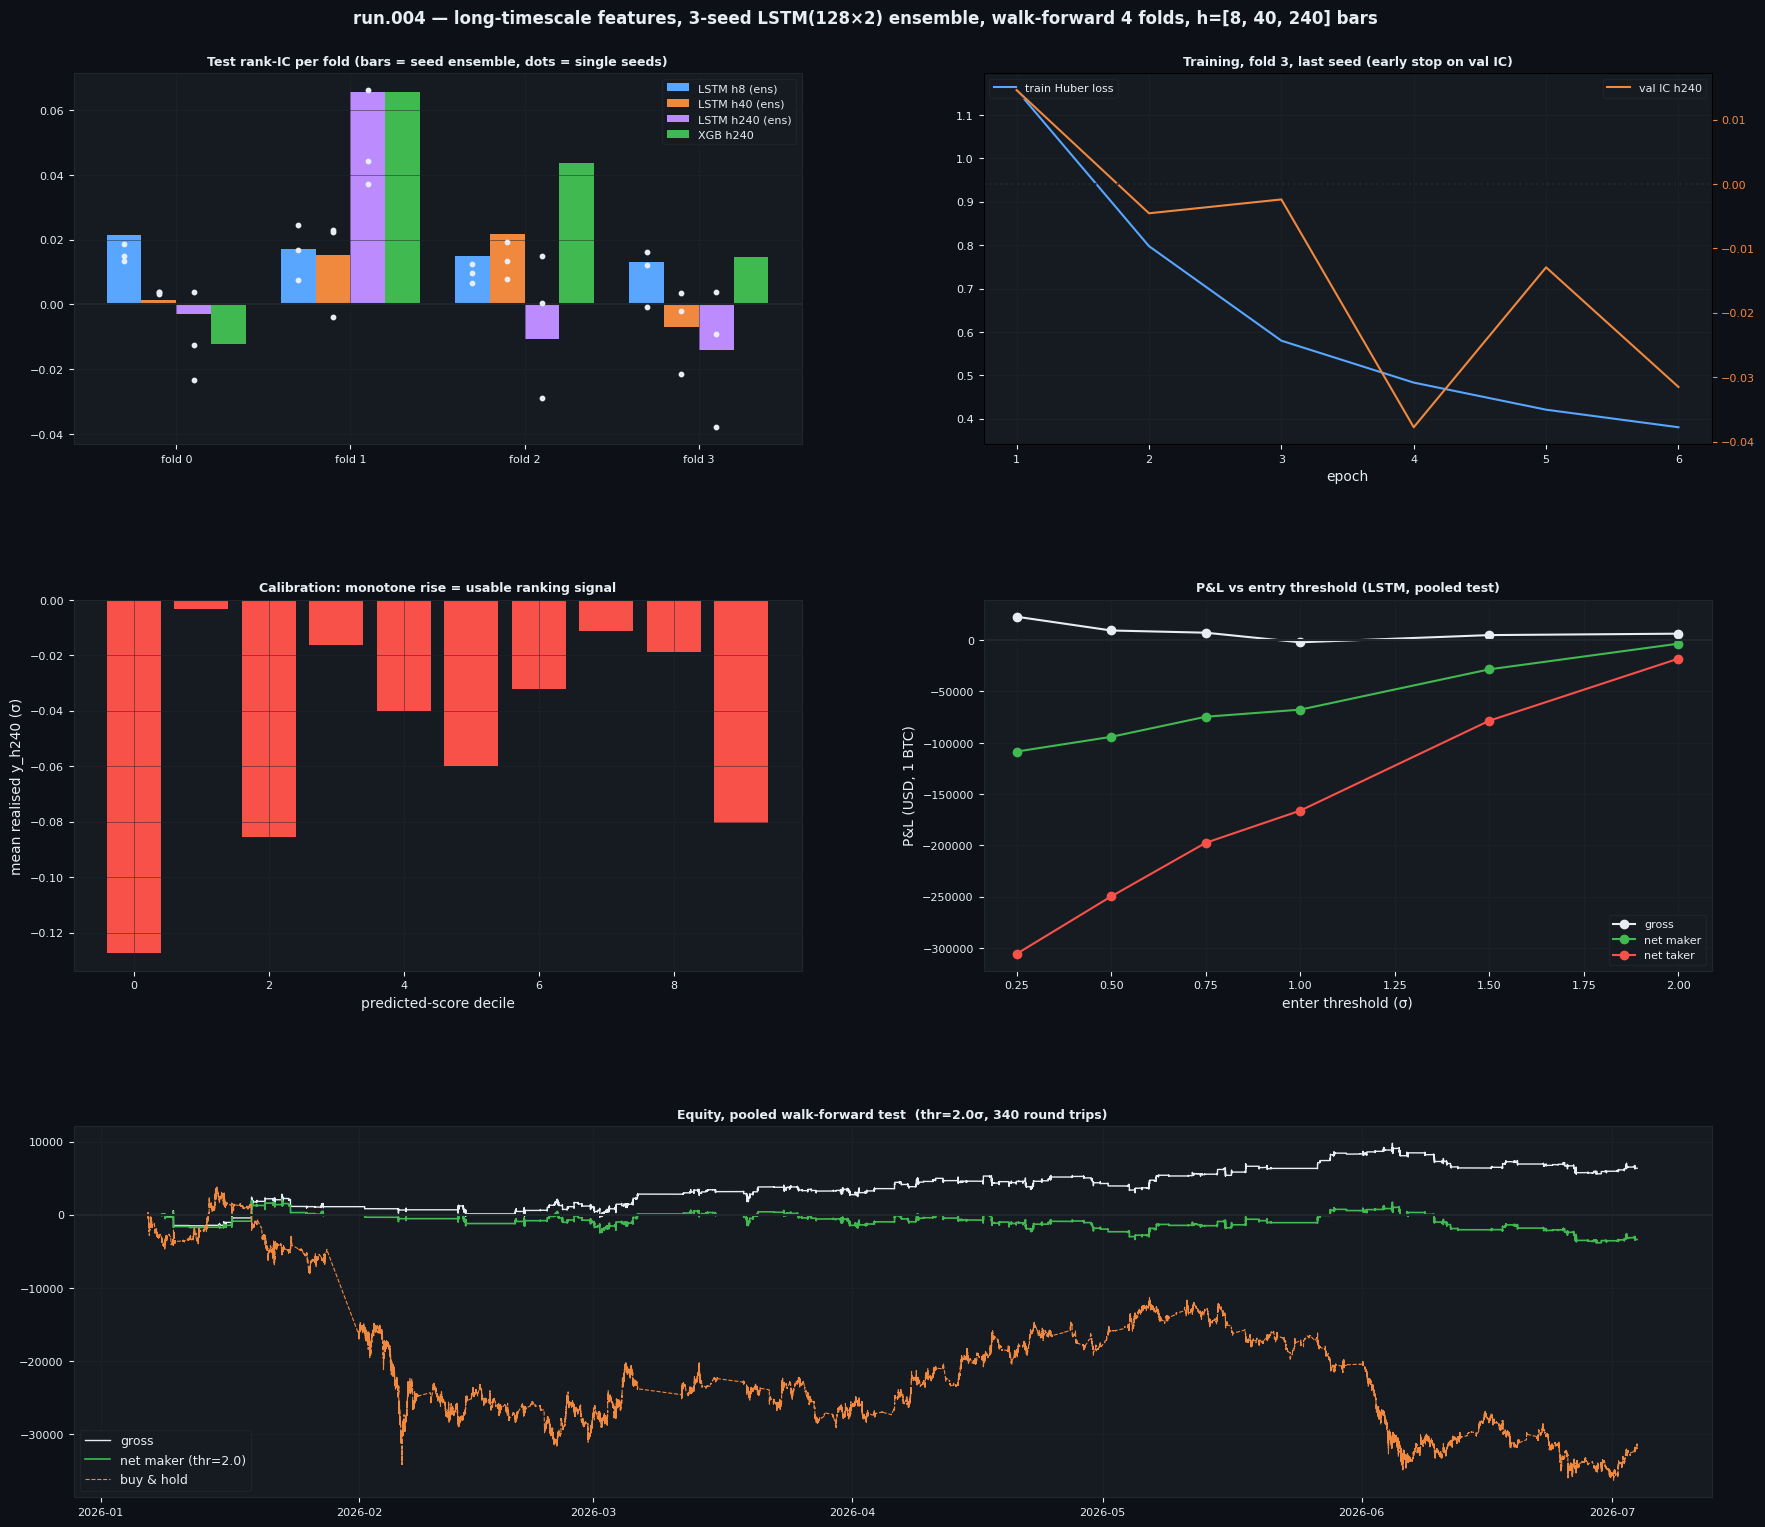

Chart saved.


In [13]:
# ── Cell 12: Plots ────────────────────────────────────────────────────────
DARK, PANEL, GRID = '#0d1117', '#161b22', '#21262d'
TEXT, UPC, DOWNC, ACCC, GOLD = '#e6edf3', '#3fb950', '#f85149', '#58a6ff', '#f0883e'

def style(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=8)
    ax.set_title(title, color=TEXT, fontsize=9, fontweight='bold', pad=6)
    for sp in ax.spines.values(): sp.set_edgecolor(GRID)
    ax.grid(color=GRID, linewidth=0.5, alpha=0.7)
    ax.yaxis.label.set_color(TEXT); ax.xaxis.label.set_color(TEXT)

fig = plt.figure(figsize=(18, 16), facecolor=DARK)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.25,
                       left=0.06, right=0.97, top=0.94, bottom=0.05)

# 1. Per-fold IC bars
ax = fig.add_subplot(gs[0, 0])
xs = np.arange(N_FOLDS)
w = 0.2
PALETTE = [ACCC, GOLD, '#bc8cff']
for j, h in enumerate(HORIZONS):
    ax.bar(xs + j * w, [r['test_ic'][j] for r in results], w,
           label=f'LSTM h{h} (ens)', color=PALETTE[j % len(PALETTE)])
    ax.scatter(np.repeat(xs + j * w, len(SEEDS)),
               [r['seed_test_ic'][s][j] for r in results for s in range(len(SEEDS))],
               s=10, color=TEXT, zorder=3)
if xgb_results:
    ax.bar(xs + len(HORIZONS) * w, [r['ic'] for r in xgb_results], w,
           label=f'XGB h{H_TRADE}', color=UPC)
ax.axhline(0, color=GRID)
ax.set_xticks(xs + 1.5 * w); ax.set_xticklabels([f'fold {k}' for k in range(N_FOLDS)])
ax.legend(facecolor=PANEL, labelcolor=TEXT, edgecolor=GRID, fontsize=8)
style(ax, 'Test rank-IC per fold (bars = seed ensemble, dots = single seeds)')

# 2. Training curve, last fold
ax = fig.add_subplot(gs[0, 1])
hist = results[-1]['hist']
ep = np.arange(1, len(hist) + 1)
ax.plot(ep, [h['train_loss'] for h in hist], color=ACCC, label='train Huber loss')
ax.legend(facecolor=PANEL, labelcolor=TEXT, edgecolor=GRID, fontsize=8, loc='upper left')
ax.set_xlabel('epoch')
axr = ax.twinx()
axr.plot(ep, [h['val_ic'][H_TRADE_IDX] for h in hist], color=GOLD, label=f'val IC h{H_TRADE}')
axr.axhline(0, color=GRID, linestyle=':')
axr.tick_params(colors=GOLD, labelsize=8)
axr.legend(facecolor=PANEL, labelcolor=TEXT, edgecolor=GRID, fontsize=8, loc='upper right')
style(ax, f'Training, fold {N_FOLDS - 1}, last seed (early stop on val IC)')

# 3. Calibration: predicted decile vs mean realised return
ax = fig.add_subplot(gs[1, 0])
y_real = Y_all[ends_pool, H_TRADE_IDX]
q = pd.qcut(score_lstm, 10, labels=False, duplicates='drop')
means = [y_real[q == i].mean() for i in range(int(np.nanmax(q)) + 1)]
ax.bar(range(len(means)), means, color=[DOWNC if v < 0 else UPC for v in means])
ax.axhline(0, color=GRID)
ax.set_xlabel('predicted-score decile')
ax.set_ylabel(f'mean realised y_h{H_TRADE} (σ)')
style(ax, 'Calibration: monotone rise = usable ranking signal')

# 4. Net P&L vs entry threshold
ax = fig.add_subplot(gs[1, 1])
if lstm_rows:
    thr_v = [r['thr'] for r in lstm_rows]
    ax.plot(thr_v, [r['gross'] for r in lstm_rows], marker='o', color=TEXT, label='gross')
    ax.plot(thr_v, [r['net_maker'] for r in lstm_rows], marker='o', color=UPC, label='net maker')
    ax.plot(thr_v, [r['net_taker'] for r in lstm_rows], marker='o', color=DOWNC, label='net taker')
ax.axhline(0, color=GRID)
ax.set_xlabel('enter threshold (σ)'); ax.set_ylabel('P&L (USD, 1 BTC)')
ax.legend(facecolor=PANEL, labelcolor=TEXT, edgecolor=GRID, fontsize=8)
style(ax, 'P&L vs entry threshold (LSTM, pooled test)')

# 5. Equity at best net-maker threshold (full width)
ax = fig.add_subplot(gs[2, :])
if lstm_rows:
    best = max(lstm_rows, key=lambda r: r['net_maker'])
    bt = best['bt']
    net_bar = np.r_[bt['pnl'], 0.0] - bt['turnover'] * MAKER_FEE
    eq_g = np.cumsum(np.r_[bt['pnl'], 0.0])
    eq_n = np.cumsum(net_bar)
    t_axis = pd.to_datetime(dt_all[ends_pool])
    ax.plot(t_axis, eq_g, color=TEXT, lw=1.0, label='gross')
    ax.plot(t_axis, eq_n, color=UPC, lw=1.2, label=f"net maker (thr={best['thr']})")
    ax.plot(t_axis, close[ends_pool] - close[ends_pool[0]], color=GOLD, lw=0.8,
            linestyle='--', label='buy & hold')
    ax.axhline(0, color=GRID)
    ax.legend(facecolor=PANEL, labelcolor=TEXT, edgecolor=GRID, fontsize=9)
    style(ax, f"Equity, pooled walk-forward test  (thr={best['thr']}σ, {best['n']:,} round trips)")

fig.suptitle(f'run.004 — long-timescale features, {len(SEEDS)}-seed LSTM({HIDDEN_DIM}×{NUM_LAYERS}) ensemble, '
             f'walk-forward {N_FOLDS} folds, h={HORIZONS} bars',
             color=TEXT, fontsize=12, fontweight='bold')
plt.savefig(os.path.join(OUTPUT_DIR, 'run004_results.png'), dpi=150,
            bbox_inches='tight', facecolor=DARK)
plt.show()
print('Chart saved.')

In [14]:
# ── Cell 13: Save models + how to read this run ───────────────────────────
save_path = os.path.join(OUTPUT_DIR, f'lstm_run004_h{H_TRADE}.pt')
torch.save({
    'model_states': results[-1]['states'],     # all seeds, last (largest-train) fold
    'scaler':       results[-1]['scaler'],
    'features':     features,
    'new_features': [f for f in NEW_FEATURES if f in features],
    'horizons':     HORIZONS,
    'seeds':        SEEDS,
    'config':       dict(seq_len=SEQ_LEN, hidden_dim=HIDDEN_DIM,
                         num_layers=NUM_LAYERS, dropout=DROPOUT,
                         vol_window=VOL_WINDOW, target_clip=TARGET_CLIP,
                         window_sec=WINDOW_SEC,
                         sample_w_base=SAMPLE_W_BASE,
                         loss_w_alpha=LOSS_W_ALPHA, loss_w_cap=LOSS_W_CAP),
    'test_ic_per_fold':      [r['test_ic'] for r in results],
    'seed_test_ic_per_fold': [r['seed_test_ic'] for r in results],
}, save_path)
print(f'Saved (last-fold seed ensemble) → {save_path}')

print('\nHow to read this run:')
print(' 1. h8/h40 per-fold ICs vs run.003 = pure effect of the new features at the')
print('    old horizons (sampling/loss/model are frozen; run.003 had no seed')
print('    ensembling, so compare against the per-seed DOTS, not the bars).')
print(' 2. h240 is the hypothesis: ensemble IC consistent in sign across folds AND')
print('    daily-IC |t| > 2 → pursue (thresholds, longer training, more seeds).')
print(' 3. XGB importance table: if the NEW features hold ~0% gain and ICs are flat,')
print('    the v1 dataset is exhausted — stop feature work here and wait for the')
print('    v3/schema-4 collector data (OFI, add/cancel flow, walls, ETH lead-lag).')
print(' 4. Per-seed spread (± in the summary) is the noise floor: any run-to-run IC')
print('    difference smaller than ~2× that spread is not evidence of anything.')

Saved (last-fold seed ensemble) → /root/btc_lstm_run004/lstm_run004_h240.pt

How to read this run:
 1. h8/h40 per-fold ICs vs run.003 = pure effect of the new features at the
    old horizons (sampling/loss/model are frozen; run.003 had no seed
    ensembling, so compare against the per-seed DOTS, not the bars).
 2. h240 is the hypothesis: ensemble IC consistent in sign across folds AND
    daily-IC |t| > 2 → pursue (thresholds, longer training, more seeds).
 3. XGB importance table: if the NEW features hold ~0% gain and ICs are flat,
    the v1 dataset is exhausted — stop feature work here and wait for the
    v3/schema-4 collector data (OFI, add/cancel flow, walls, ETH lead-lag).
 4. Per-seed spread (± in the summary) is the noise floor: any run-to-run IC
    difference smaller than ~2× that spread is not evidence of anything.
